In [2]:
!pip install astropy
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
import scipy 
import urllib.request
import os 
import gzip
import shutil


In [3]:
NGC2660_fits = "hst_10634_03_acs_wfc_total_j9dm03.fits"
NGC2660_gz = "hst_10634_03_acs_wfc_total_j9dm03.fits.gz"
NGC2660_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&dataset=hst_10634_03_acs_wfc_total_j9dm03"


if not os.path.exists(NGC2660_fits):
    if not os.path.exists(NGC2660_gz):
        try:
            urllib.request.urlretrieve(NGC2660_fits_url, NGC2660_fits)
            print(f"Downloaded {NGC2660_fits}")
        except Exception as e:
            print("Error Downloading File")
            NGC2660_fits = None


Filename: hst_10634_03_acs_wfc_total_j9dm03.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     926   ()      
  1  SCI           1 ImageHDU        90   (5383, 5398)   float32   
  2  WHT           1 ImageHDU        45   (5383, 5398)   float32   
  3  CTX           1 ImageHDU        38   (5383, 5398)   int32   
  4  HDRTAB        1 BinTableHDU    638   8R x 314C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, K, 4A, K, K, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, 4A, 4A, L, D, D, D, 3A, 1A, K, D, D, D, 24A, 3A, 4A, 4A, 12A, 12A, 23A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 23A, 4A, 8A, 7A, 23A, D, K, D, 6A, 9A, 8A, D, D, L, 4A, 44A, 3A, K, 7A, 7A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, 23A, L, 1A, 3A, 1A, D, 3A, 6A, K, D, D, D, D, D, D, D, D, D, D, 23A, D, 

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


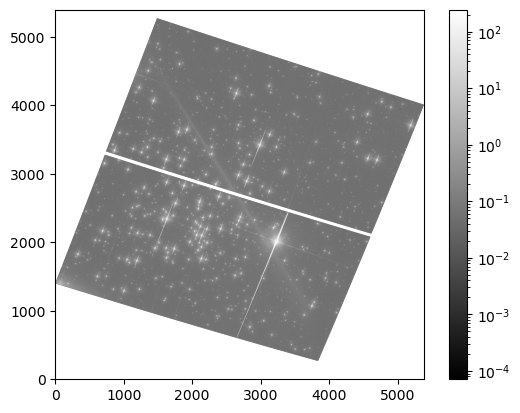

In [4]:
from matplotlib.colors import LogNorm

HDUList = fits.open(NGC2660_fits)

HDUList.info()

image_data = HDUList[1].data #reads the data from the SCI section of the fits file
print(image_data)
plt.figure()
plt.imshow(image_data, cmap='gray', origin = 'lower', norm=LogNorm())
plt.colorbar()
plt.show()

HDUList.close()


sigma = 3
fwhm = 2.355 * sigma


In [ ]:
import array


clipped_data = image_data.copy()
for i in range(5):
    mean = np.mean(clipped_data)
    std = np.std(clipped_data)
    mask = np.abs(clipped_data - mean) < 3 * std
    clipped_data = clipped_data[mask]
background_mean = np.mean(clipped_data)

print(clipped_data)
print(mask)

print(mask.shape)




#gaussian_PSF

[0. 0. 0. ... 0. 0. 0.]
[ True  True  True ...  True  True  True]
(27885898,)


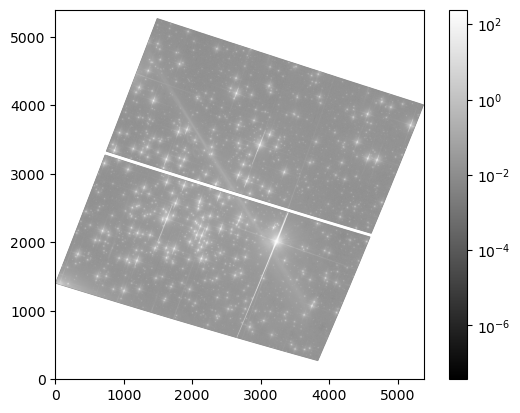

(array([7.0000000e+00, 1.1000000e+01, 2.7000000e+01, 1.2698643e+07,
        1.3000000e+03, 7.9319000e+04, 3.6838000e+06, 6.9273560e+06,
        2.3324720e+06, 9.0661000e+05, 4.8858800e+05, 3.1470700e+05,
        2.2353800e+05, 1.6457800e+05, 1.2665500e+05, 1.0050300e+05,
        8.1478000e+04, 6.8278000e+04, 5.8037000e+04, 4.9598000e+04,
        4.2880000e+04, 3.7686000e+04, 3.3527000e+04, 2.9922000e+04,
        2.6976000e+04, 2.4434000e+04, 2.2137000e+04, 1.9770000e+04,
        1.8329000e+04, 1.6934000e+04, 1.5491000e+04, 1.4273000e+04,
        1.3438000e+04, 1.2352000e+04, 1.1426000e+04, 1.0859000e+04,
        1.0163000e+04, 9.4640000e+03, 8.8140000e+03, 8.3500000e+03,
        7.7550000e+03, 7.1400000e+03, 7.0330000e+03, 6.5350000e+03,
        6.2280000e+03, 5.8450000e+03, 5.4660000e+03, 5.0790000e+03,
        4.8620000e+03, 4.5640000e+03]),
 array([-0.1       , -0.083     , -0.066     , -0.049     , -0.032     ,
        -0.015     ,  0.002     ,  0.019     ,  0.036     ,  0.053     

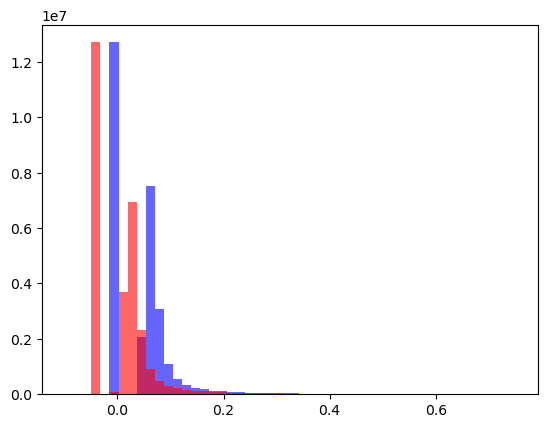

In [6]:
subtracted_image = image_data - background_mean

plt.figure()
plt.imshow(subtracted_image, cmap='gray', origin = 'lower', norm=LogNorm())
plt.colorbar()
plt.show()

fig, axes = plt.subplots()
axes.hist(image_data.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
axes.hist(subtracted_image.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

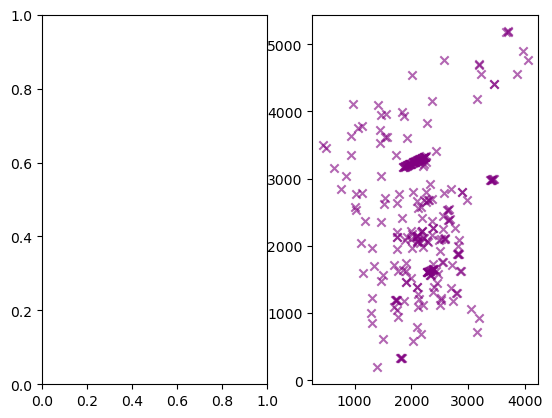

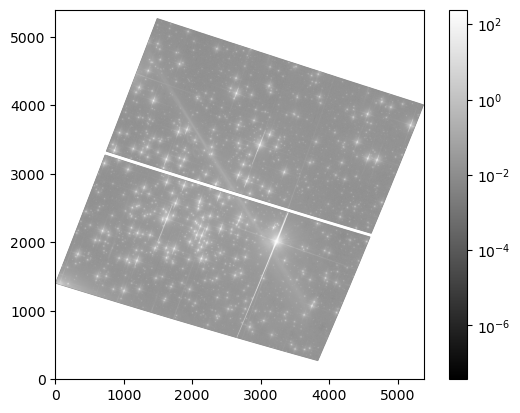

In [7]:
subtracted_image = image_data - background_mean

detection_threshold = 5500 * background_mean

filter = int(np.ceil(fwhm))

local_max = scipy.ndimage.maximum_filter(subtracted_image, size=filter)

peaks = (subtracted_image == local_max) & (subtracted_image > detection_threshold)

detections_x, detections_y = np.where(peaks)

fig, axes = plt.subplots(1, 2)

plt.figure()
plt.imshow(subtracted_image, cmap='gray', origin = 'lower', norm=LogNorm())
axes[1].scatter(detections_x, detections_y, color = 'purple', alpha =.6, marker='x')
plt.colorbar()
plt.show()


#axes[2].hist(image_data.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
#axes[2].hist(subtracted_image.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

In [8]:
np.zeros(image_data[(1000, 2500), (2500,3400)])
plt.figure()
plt.imshow(image_data, cmap='gray', origin = 'lower', norm=LogNorm())
plt.colorbar()
plt.show()

TypeError: 'numpy.float32' object cannot be interpreted as an integer